In [1]:
import torch
import torch.nn.functional as F


In [2]:
from audio_classification_playground.vox_profile.emotion.wavlm_emotion_dim import WavLMWrapper
from audio_classification_playground.vox_profile.emotion.whisper_emotion_dim import WhisperWrapper

In [6]:
device = torch.device("cuda") if torch.cuda.is_available() else "cpu"

model = WhisperWrapper.from_pretrained("tiantiaf/whisper-large-v3-msp-podcast-emotion-dim").to(device)
model = model.eval()

Some weights of WhisperModel were not initialized from the model checkpoint at openai/whisper-large-v3 and are newly initialized because the shapes did not match:
- encoder.embed_positions.weight: found shape torch.Size([1500, 1280]) in the checkpoint and torch.Size([750, 1280]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [3]:
device = torch.device("cuda") if torch.cuda.is_available() else "cpu"
# Load model from Huggingface
model = WavLMWrapper.from_pretrained("tiantiaf/wavlm-large-msp-podcast-emotion-dim").to(device)
model = model.eval()

config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

In [4]:
import librosa
import torch
import torch.nn.functional as F
SR = 16_000
WINDOW_SEC = 3.5
HOP_SEC = 0.25
BATCH_SIZE = 128
window_samples = int(WINDOW_SEC * SR)   # 56,000
hop_samples = int(HOP_SEC * SR)         # 16,000

In [5]:
audio_path = "/workspace/tmp_data/robbiestaniforth-2026-2-9__14-44-54.mp3"
audio,_ = librosa.load(audio_path, sr=SR, mono=True)

In [6]:
audio.shape[0]/SR/60

74.51740625000001

In [8]:
# 2. Convert to tensor
audio_t = torch.from_numpy(audio).float()
# 3. Pad so the last partial window isn't silently dropped
remainder = (len(audio_t) - window_samples) % hop_samples
if remainder != 0:
    pad_needed = hop_samples - remainder
    audio_t = F.pad(audio_t, (0, pad_needed))
# 4. Unfold into overlapping windows  →  [N, window_samples]
#    unfold(dim, size, step) returns a view — no copy
windows = audio_t.unfold(0, window_samples, hop_samples)
# 5. Batch inference
all_arousal, all_valence, all_dominance = [], [], []
for i in range(0, len(windows), BATCH_SIZE):
    batch = windows[i : i + BATCH_SIZE].to(device)
    with torch.no_grad():
        a, v, d = model(batch)
    all_arousal.append(a.cpu())
    all_valence.append(v.cpu())
    all_dominance.append(d.cpu())
arousal   = torch.cat(all_arousal).squeeze(-1).numpy()    # [N]
valence   = torch.cat(all_valence).squeeze(-1).numpy()
dominance = torch.cat(all_dominance).squeeze(-1).numpy()


/workspace/audio-classification-playground/.venv/lib/python3.10/site-packages/torch/nn/functional.py:6371: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(


In [9]:
# pod_arousal = arousal
# pod_valence = valence
# pod_dominance = dominance


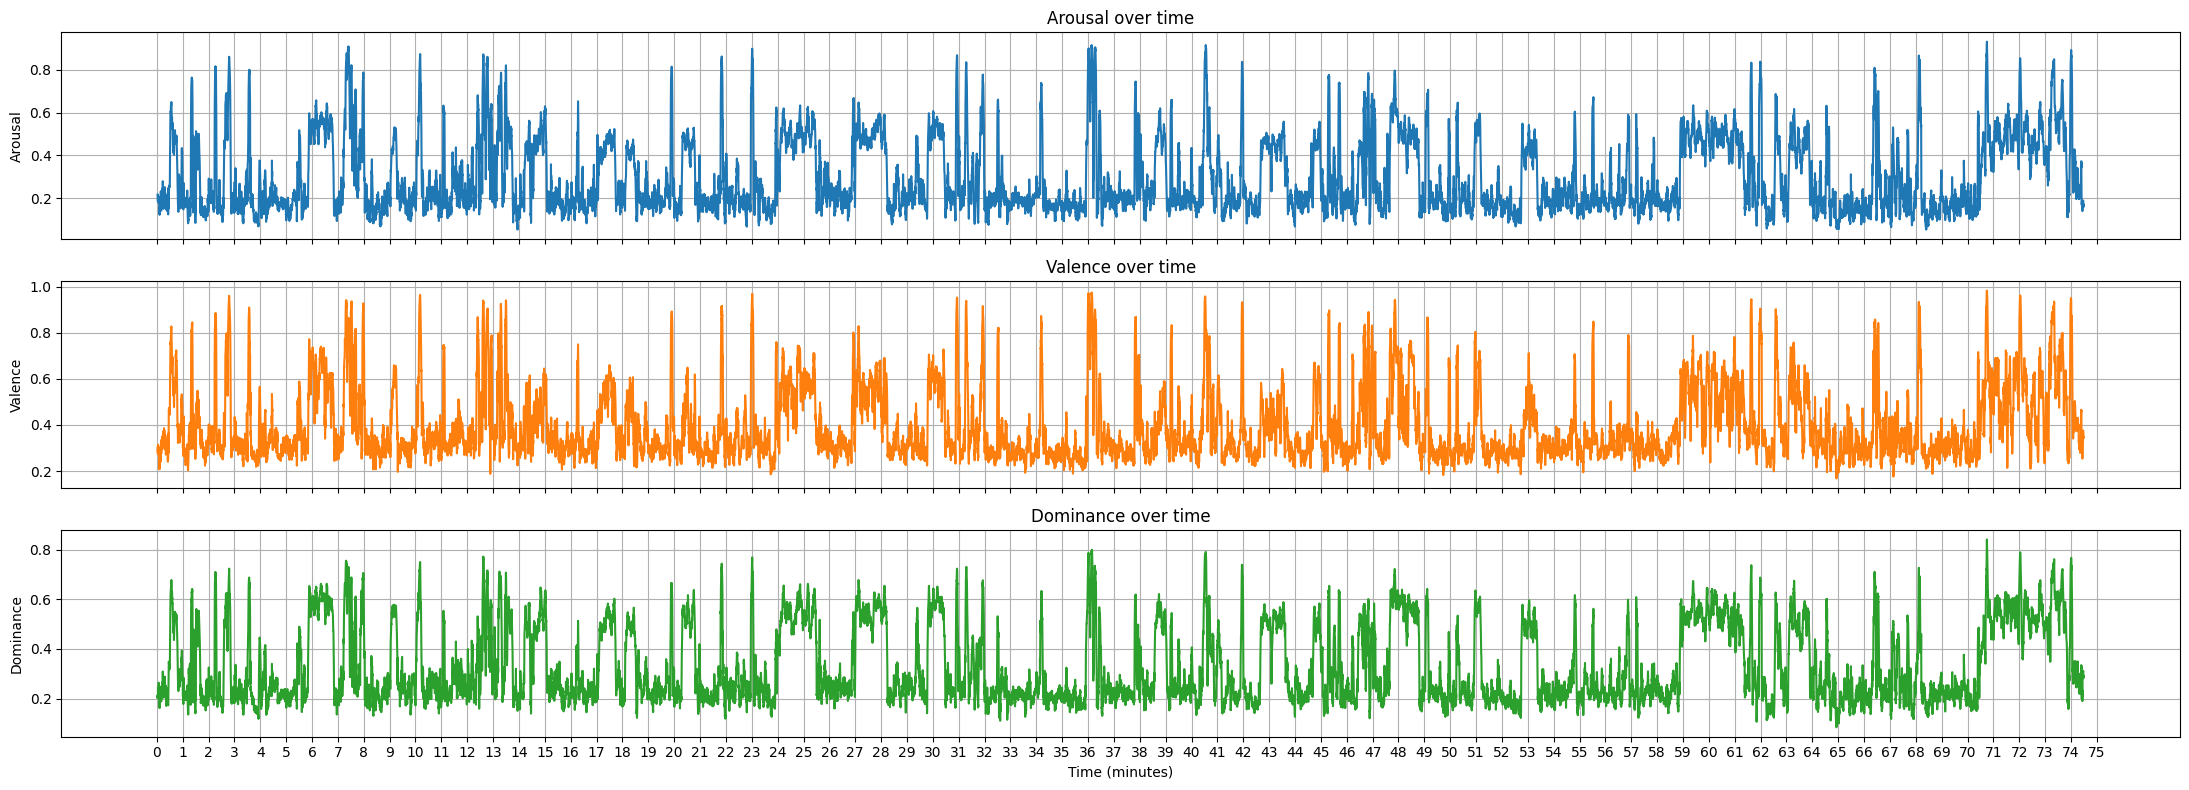

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker

# Compute time axis for center of each window, in seconds first
num_windows = len(arousal)
window_centers_sec = np.arange(num_windows) * HOP_SEC + WINDOW_SEC / 2
window_centers_min = window_centers_sec / 60.0

fig, axs = plt.subplots(3, 1, figsize=(22, 8), sharex=True)  # Widens the figure more

# Set major ticks at every minute (floor to closest integer min, up to last min)
time_min_max = window_centers_min[-1]
minute_ticks = np.arange(0, time_min_max + 1, 1)
axs[-1].set_xticks(minute_ticks)

axs[0].plot(window_centers_min, arousal, label="Arousal", color="tab:blue")
axs[0].set_ylabel("Arousal")
axs[0].set_title("Arousal over time")
axs[0].grid(True)
axs[0].set_xticks(minute_ticks)
axs[0].set_xticklabels([f"{tick:.0f}" for tick in minute_ticks])

axs[1].plot(window_centers_min, valence, label="Valence", color="tab:orange")
axs[1].set_ylabel("Valence")
axs[1].set_title("Valence over time")
axs[1].grid(True)
axs[1].set_xticks(minute_ticks)
axs[1].set_xticklabels([f"{tick:.0f}" for tick in minute_ticks])

axs[2].plot(window_centers_min, dominance, label="Dominance", color="tab:green")
axs[2].set_xlabel("Time (minutes)")
axs[2].set_ylabel("Dominance")
axs[2].set_title("Dominance over time")
axs[2].grid(True)
axs[2].set_xticks(minute_ticks)
axs[2].set_xticklabels([f"{tick:.0f}" for tick in minute_ticks])

# Format the x-axis as integer minutes
axs[2].xaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))

plt.tight_layout()
plt.show()

In [11]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── VAD Configuration ────────────────────────────────────────────────────────
VAD_CONFIG = {
    "speech_threshold": 0.4,         # Silero probability threshold
    "min_speech_sec": 0.1,           # discard speech blocks shorter than this
    "min_silence_sec": 1.2,         # bridge silence gaps shorter than this (keeps utterances whole)
    "speech_ratio_threshold": 0.1,   # fraction of 3.5s window that must be speech
}

# ── Load Silero VAD ──────────────────────────────────────────────────────────
vad_model, vad_utils = torch.hub.load(
    repo_or_dir='snakers4/silero-vad',
    model='silero_vad',
    force_reload=False,
    trust_repo=True,
)
(get_speech_timestamps, _, read_audio, _, _) = vad_utils


Using cache found in /workspace/.cache/torch/hub/snakers4_silero-vad_master


In [12]:

# ── Run VAD at native resolution ─────────────────────────────────────────────
# Silero VAD expects 16kHz mono float32 tensor
audio_tensor = torch.from_numpy(audio).float()

speech_timestamps = get_speech_timestamps(
    audio_tensor,
    vad_model,
    sampling_rate=SR,
    threshold=VAD_CONFIG["speech_threshold"],
    min_speech_duration_ms=int(VAD_CONFIG["min_speech_sec"] * 1000),
    min_silence_duration_ms=int(VAD_CONFIG["min_silence_sec"] * 1000),
    return_seconds=False,
)


[{'start': 461344, 'end': 474080},
 {'start': 511520, 'end': 774624},
 {'start': 877600, 'end': 892896},
 {'start': 915488, 'end': 960992},
 {'start': 1202720, 'end': 1221600},
 {'start': 1289760, 'end': 1304544},
 {'start': 1379872, 'end': 1390048},
 {'start': 1476128, 'end': 1490400},
 {'start': 1516064, 'end': 1597920},
 {'start': 1840160, 'end': 1852384},
 {'start': 2169376, 'end': 2178528},
 {'start': 2497568, 'end': 2540000},
 {'start': 2564640, 'end': 2613728},
 {'start': 2655776, 'end': 2676704},
 {'start': 3366432, 'end': 3442144},
 {'start': 3811360, 'end': 3835360},
 {'start': 3972128, 'end': 3980768},
 {'start': 4007968, 'end': 4030432},
 {'start': 5229600, 'end': 5245920},
 {'start': 5289504, 'end': 5349344},
 {'start': 5633568, 'end': 6555104},
 {'start': 6952480, 'end': 7031776},
 {'start': 7205408, 'end': 7219680},
 {'start': 7574048, 'end': 7655392},
 {'start': 7686176, 'end': 7695840},
 {'start': 8693280, 'end': 8906720},
 {'start': 9643552, 'end': 9756640},
 {'start'

In [14]:

# ── Build sample-level speech mask ───────────────────────────────────────────
speech_mask_samples = np.zeros(len(audio), dtype=bool)
for ts in speech_timestamps:
    speech_mask_samples[ts['start']:ts['end']] = True


/workspace/tmp/ipykernel_1095045/3043893377.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/workspace/audio-classification-playground/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


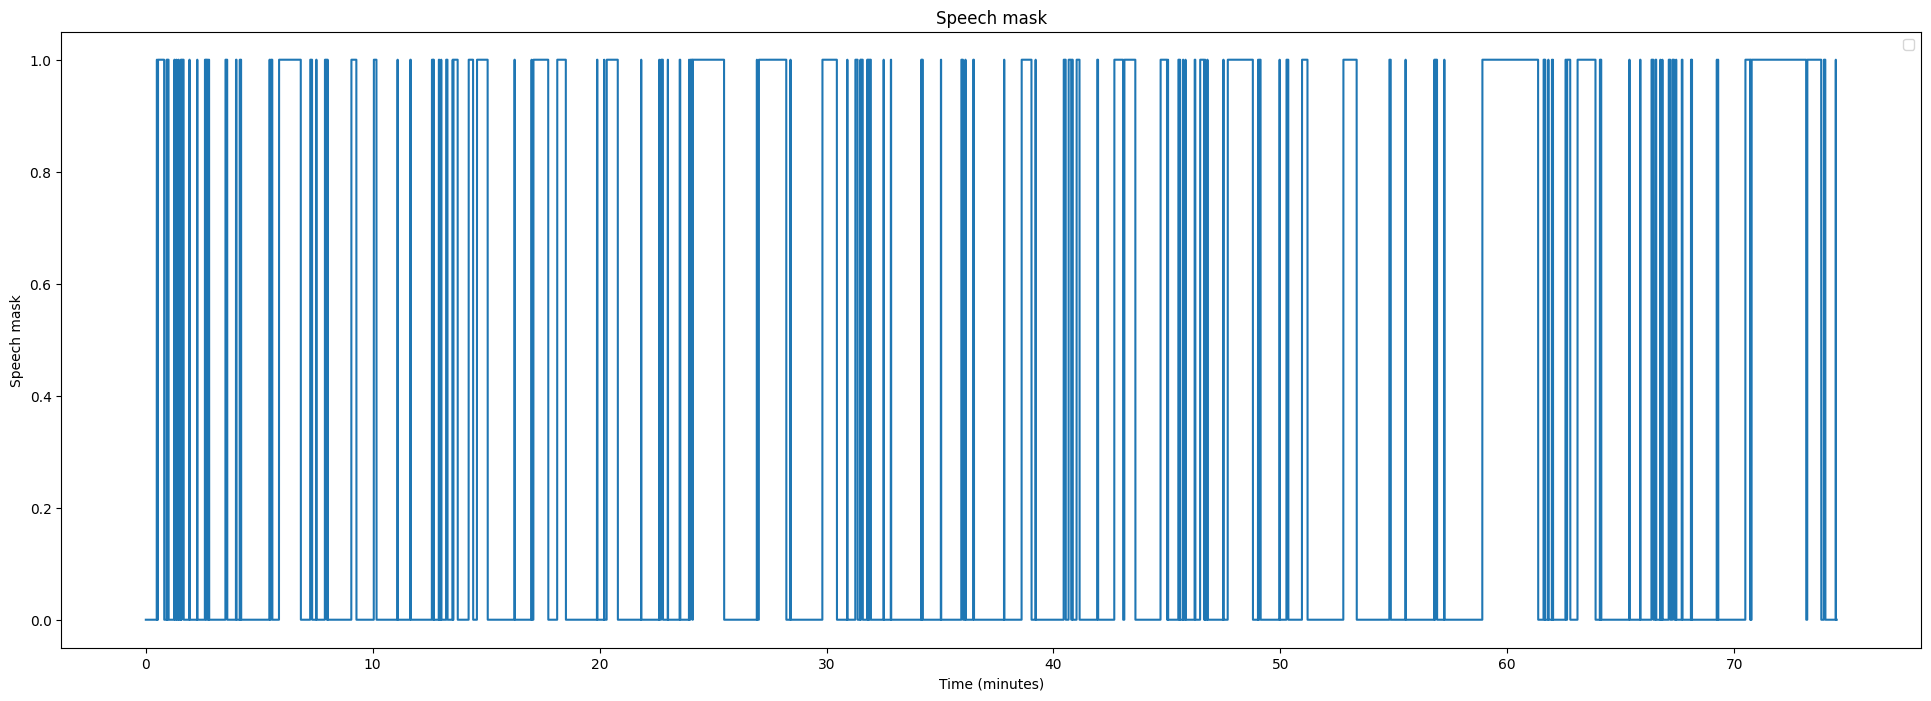

In [15]:
fig, ax = plt.subplots(figsize=(24, 8))
ax.plot(np.arange(len(audio))/SR/60, speech_mask_samples)
ax.set_xlabel("Time (minutes)")
ax.set_ylabel("Speech mask")
ax.set_title("Speech mask")
ax.legend()
plt.show()



In [16]:

# ── Align to prediction frame grid ──────────────────────────────────────────
# Each prediction frame t covers a window: [t * hop_samples, t * hop_samples + window_samples)
# Compute speech ratio for each window
n_frames = len(arousal)
hop_samples = int(HOP_SEC * SR)
window_samples = int(WINDOW_SEC * SR)

speech_ratio = np.zeros(n_frames, dtype=np.float32)
for t in range(n_frames):
    win_start = t * hop_samples
    win_end = min(win_start + window_samples, len(speech_mask_samples))
    if win_end > win_start:
        speech_ratio[t] = speech_mask_samples[win_start:win_end].mean()

# Binary mask: frame is "speech" if enough of its window contains speech
speech_mask = speech_ratio >= VAD_CONFIG["speech_ratio_threshold"]


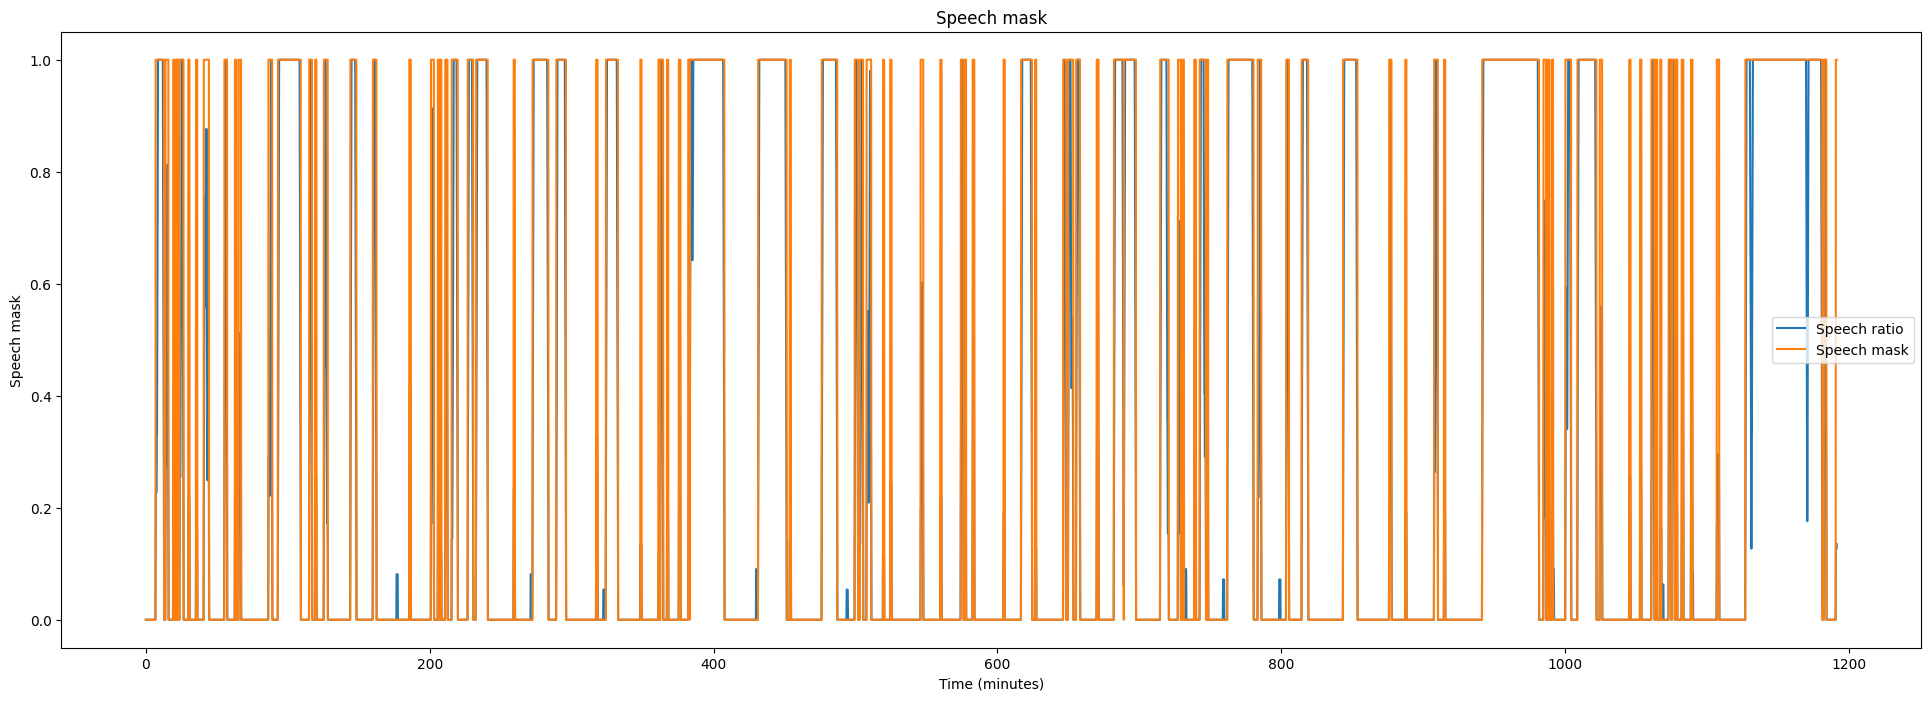

In [18]:
fig, ax = plt.subplots(figsize=(24, 8))
ax.plot(np.arange(len(speech_mask))/HOP_SEC/60, speech_ratio,label="Speech ratio")
ax.plot(np.arange(len(speech_mask))/HOP_SEC/60, speech_mask,label="Speech mask")
ax.set_xlabel("Time (minutes)")
ax.set_ylabel("Speech mask")
ax.set_title("Speech mask")
ax.legend()
plt.show()



In [19]:

# ── Build speech block list ──────────────────────────────────────────────────
def mask_to_blocks(mask):
    """Convert boolean mask to list of (start_frame, end_frame) tuples."""
    blocks = []
    in_block = False
    for t in range(len(mask)):
        if mask[t] and not in_block:
            start = t
            in_block = True
        elif not mask[t] and in_block:
            blocks.append((start, t - 1))
            in_block = False
    if in_block:
        blocks.append((start, len(mask) - 1))
    return blocks

speech_blocks = mask_to_blocks(speech_mask)

# ── Summary ──────────────────────────────────────────────────────────────────
total_frames = len(arousal)
speech_frames = speech_mask.sum()
speech_pct = 100.0 * speech_frames / total_frames
total_dur = total_frames * HOP_SEC
speech_dur = speech_frames * HOP_SEC

print(f"Total frames:    {total_frames}  ({total_dur / 60:.1f} min)")
print(f"Speech frames:   {speech_frames}  ({speech_dur / 60:.1f} min,  {speech_pct:.1f}%)")
print(f"Silence frames:  {total_frames - speech_frames}  ({(total_dur - speech_dur) / 60:.1f} min)")
print(f"Speech blocks:   {len(speech_blocks)}")
print()

block_durations = [(e - s + 1) * HOP_SEC for s, e in speech_blocks]
print(f"Block duration stats:")
print(f"  min:    {min(block_durations):.1f}s")
print(f"  median: {np.median(block_durations):.1f}s")
print(f"  mean:   {np.mean(block_durations):.1f}s")
print(f"  max:    {max(block_durations):.1f}s")
print(f"  >10s:   {sum(1 for d in block_durations if d > 10)}")


Total frames:    17872  (74.5 min)
Speech frames:   6279  (26.2 min,  35.1%)
Silence frames:  11593  (48.3 min)
Speech blocks:   97

Block duration stats:
  min:    2.8s
  median: 7.2s
  mean:   16.2s
  max:    203.5s
  >10s:   32


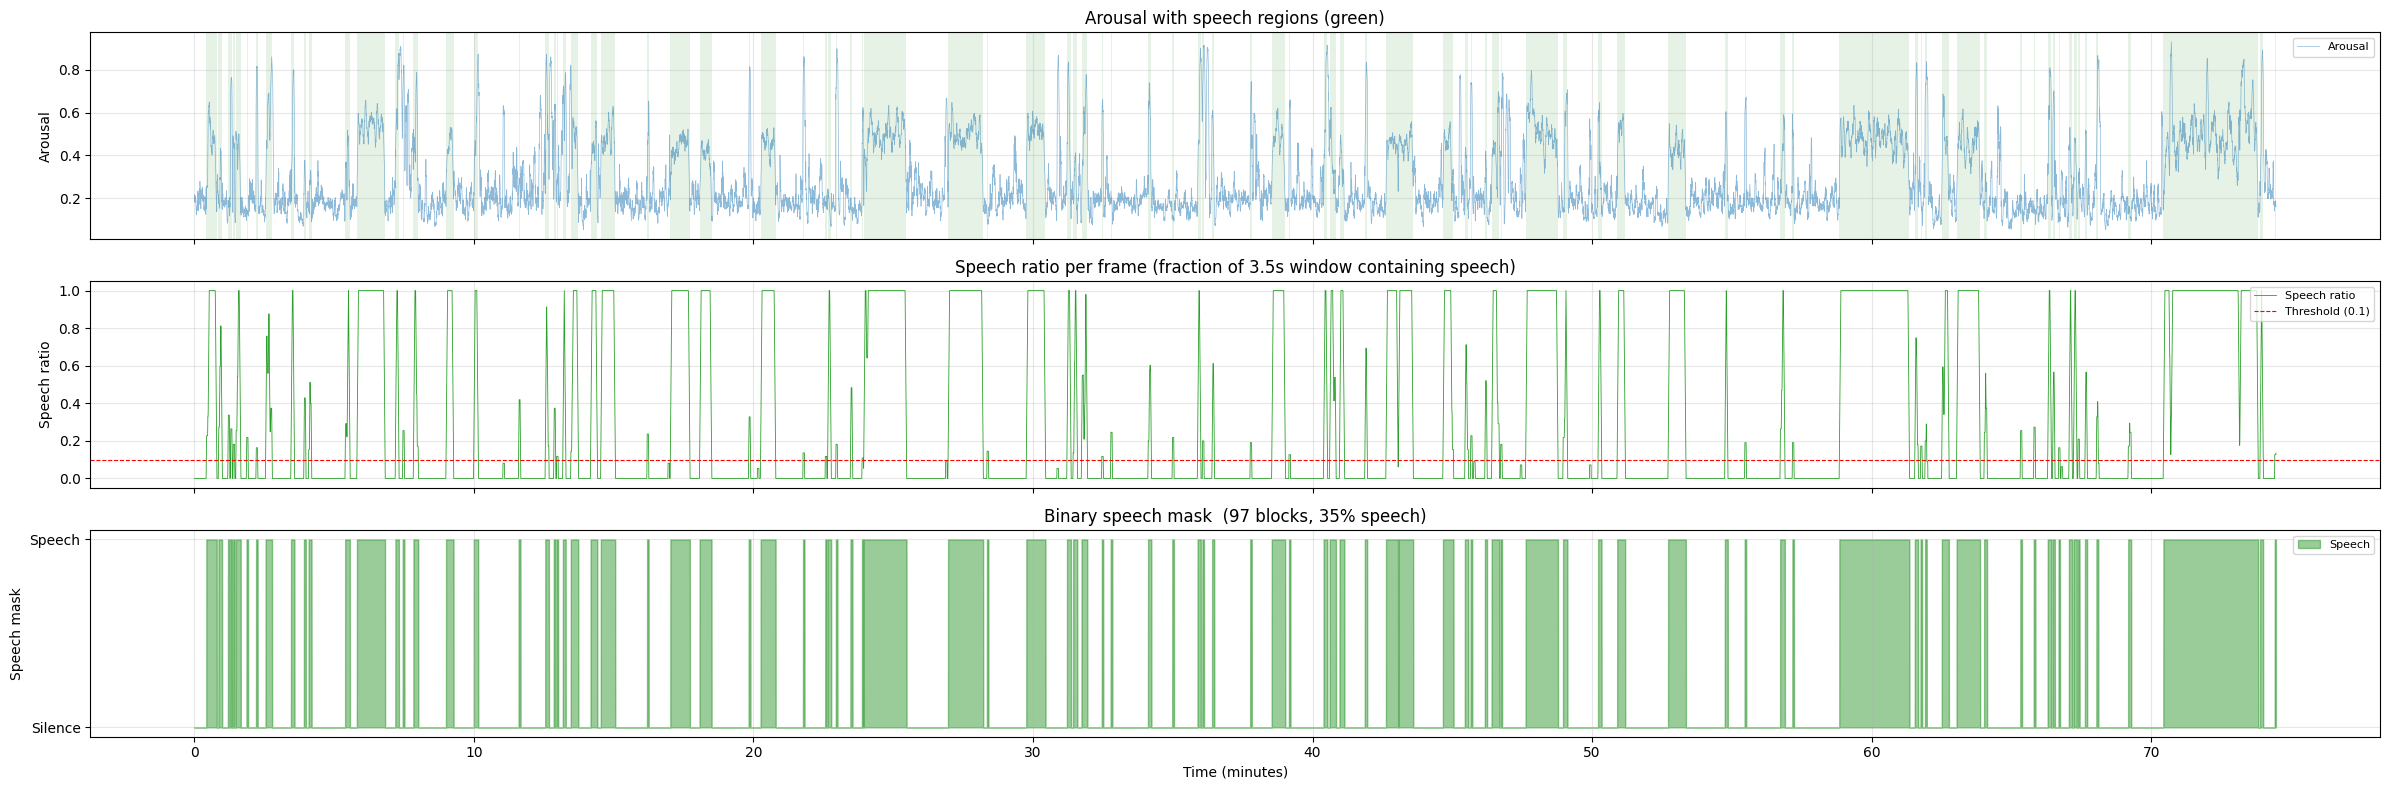

In [20]:

# ── Visualization ────────────────────────────────────────────────────────────
time_min = np.arange(n_frames) * HOP_SEC / 60.0

fig, axs = plt.subplots(3, 1, figsize=(24, 8), sharex=True)

# Panel 1: raw arousal with speech mask overlay
ax = axs[0]
ax.plot(time_min, arousal, alpha=0.5, linewidth=0.5, color="tab:blue", label="Arousal")
for s, e in speech_blocks:
    ax.axvspan(time_min[s], time_min[e], alpha=0.1, color="green", linewidth=0)
ax.set_ylabel("Arousal")
ax.set_title("Arousal with speech regions (green)")
ax.legend(loc="upper right", fontsize=8)
ax.grid(True, alpha=0.3)

# Panel 2: speech ratio per frame
ax = axs[1]
ax.plot(time_min, speech_ratio, linewidth=0.6, color="tab:green", label="Speech ratio")
ax.axhline(VAD_CONFIG["speech_ratio_threshold"], color="red", linestyle="--",
           linewidth=0.8, label=f"Threshold ({VAD_CONFIG['speech_ratio_threshold']})")
ax.set_ylabel("Speech ratio")
ax.set_title("Speech ratio per frame (fraction of 3.5s window containing speech)")
ax.legend(loc="upper right", fontsize=8)
ax.grid(True, alpha=0.3)

# Panel 3: speech mask (binary)
ax = axs[2]
ax.fill_between(time_min, 0, speech_mask.astype(float), alpha=0.4, color="green", label="Speech")
ax.set_ylabel("Speech mask")
ax.set_title(f"Binary speech mask  ({len(speech_blocks)} blocks, {speech_pct:.0f}% speech)")
ax.set_yticks([0, 1])
ax.set_yticklabels(["Silence", "Speech"])
ax.legend(loc="upper right", fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_xlabel("Time (minutes)")

plt.tight_layout()
plt.show()

In [21]:
import numpy as np
import pandas as pd
from scipy.stats import median_abs_deviation

signals = {"Arousal": arousal, "Valence": valence, "Dominance": dominance}

# ── 1. Global descriptive stats ──────────────────────────────────────────────
print("=" * 70)
print("1. GLOBAL DESCRIPTIVE STATISTICS")
print("=" * 70)
rows = []
for name, sig in signals.items():
    mad = median_abs_deviation(sig, scale=1.0)
    rows.append({
        "Signal": name,
        "Mean": f"{sig.mean():.4f}",
        "Median": f"{np.median(sig):.4f}",
        "Std": f"{sig.std():.4f}",
        "MAD": f"{mad:.4f}",
        "MAD/Std": f"{mad / sig.std():.3f}",
        "Min": f"{sig.min():.4f}",
        "Max": f"{sig.max():.4f}",
        "N_frames": len(sig),
    })
print(pd.DataFrame(rows).to_string(index=False))
print(f"\nHOP_SEC = {HOP_SEC}  →  total duration ≈ {len(arousal) * HOP_SEC / 60:.1f} min")
print("(MAD/Std ≈ 0.675 for Gaussian; lower means heavy tails / outliers)\n")


1. GLOBAL DESCRIPTIVE STATISTICS
   Signal   Mean Median    Std    MAD MAD/Std    Min    Max  N_frames
  Arousal 0.3020 0.2231 0.1767 0.0820   0.464 0.0527 0.9318     17872
  Valence 0.4007 0.3374 0.1614 0.0651   0.404 0.1682 0.9823     17872
Dominance 0.3349 0.2608 0.1576 0.0715   0.454 0.0841 0.8412     17872

HOP_SEC = 0.25  →  total duration ≈ 74.5 min
(MAD/Std ≈ 0.675 for Gaussian; lower means heavy tails / outliers)



In [22]:

# ── 2. Autocorrelation at short lags ─────────────────────────────────────────
print("=" * 70)
print("2. AUTOCORRELATION AT SHORT LAGS")
print("=" * 70)
lags = [1, 2, 4, 8, 16, 32]
acf_rows = []
for name, sig in signals.items():
    sig_centered = sig - sig.mean()
    var = np.var(sig_centered)
    acf_vals = {}
    for lag in lags:
        if lag < len(sig):
            acf = np.mean(sig_centered[:-lag] * sig_centered[lag:]) / var
            acf_vals[f"lag {lag} ({lag * HOP_SEC:.2f}s)"] = f"{acf:.4f}"
        else:
            acf_vals[f"lag {lag} ({lag * HOP_SEC:.2f}s)"] = "N/A"
    acf_rows.append({"Signal": name, **acf_vals})
print(pd.DataFrame(acf_rows).to_string(index=False))
print()


2. AUTOCORRELATION AT SHORT LAGS
   Signal lag 1 (0.25s) lag 2 (0.50s) lag 4 (1.00s) lag 8 (2.00s) lag 16 (4.00s) lag 32 (8.00s)
  Arousal        0.9826        0.9630        0.9063        0.7710         0.5407         0.4129
  Valence        0.9757        0.9470        0.8719        0.7029         0.4360         0.3274
Dominance        0.9858        0.9706        0.9267        0.8233         0.6406         0.5144



In [23]:

# ── 3. Stationarity: per-chunk statistics ────────────────────────────────────
print("=" * 70)
print("3. STATIONARITY CHECK (per-chunk mean / std)")
print("=" * 70)
n_chunks = 6
chunk_size = len(arousal) // n_chunks
for name, sig in signals.items():
    print(f"\n  {name}:")
    print(f"  {'Chunk':<12} {'Time span':<20} {'Mean':>8} {'Std':>8} {'Median':>8}")
    print(f"  {'-'*60}")
    for i in range(n_chunks):
        start_idx = i * chunk_size
        end_idx = (i + 1) * chunk_size if i < n_chunks - 1 else len(sig)
        chunk = sig[start_idx:end_idx]
        t0 = start_idx * HOP_SEC / 60
        t1 = end_idx * HOP_SEC / 60
        print(f"  {i+1:<12} {t0:>5.1f}–{t1:>5.1f} min     {chunk.mean():>8.4f} {chunk.std():>8.4f} {np.median(chunk):>8.4f}")

print()


3. STATIONARITY CHECK (per-chunk mean / std)

  Arousal:
  Chunk        Time span                Mean      Std   Median
  ------------------------------------------------------------
  1              0.0– 12.4 min       0.2918   0.1840   0.2109
  2             12.4– 24.8 min       0.3035   0.1712   0.2276
  3             24.8– 37.2 min       0.3024   0.1791   0.2196
  4             37.2– 49.6 min       0.3128   0.1717   0.2353
  5             49.6– 62.0 min       0.2847   0.1581   0.2136
  6             62.0– 74.5 min       0.3170   0.1921   0.2445

  Valence:
  Chunk        Time span                Mean      Std   Median
  ------------------------------------------------------------
  1              0.0– 12.4 min       0.4074   0.1676   0.3391
  2             12.4– 24.8 min       0.3969   0.1514   0.3425
  3             24.8– 37.2 min       0.3976   0.1665   0.3243
  4             37.2– 49.6 min       0.4015   0.1637   0.3378
  5             49.6– 62.0 min       0.3829   0.1433   0.32

In [24]:

# ── 4. Rolling MAD distribution (baseline window = 45s) ─────────────────────
print("=" * 70)
print("4. ROLLING MAD DISTRIBUTION (45s window)")
print("=" * 70)
baseline_window = int(45.0 / HOP_SEC)
print(f"   baseline window = {baseline_window} frames = {baseline_window * HOP_SEC:.0f}s\n")

for name, sig in signals.items():
    s = pd.Series(sig)
    rolling_med = s.rolling(baseline_window, center=True, min_periods=baseline_window // 2).median()
    rolling_mad = (s - rolling_med).abs().rolling(baseline_window, center=True, min_periods=baseline_window // 2).median()
    mad_vals = rolling_mad.dropna().values
    print(f"  {name}:")
    print(f"    Rolling MAD  —  median: {np.median(mad_vals):.4f},  "
          f"min: {mad_vals.min():.4f},  max: {mad_vals.max():.4f},  "
          f"std: {mad_vals.std():.4f},  CoV: {mad_vals.std() / np.median(mad_vals):.3f}")
print("\n(CoV = coefficient of variation of the MAD; >0.3 means noise floor varies a lot)\n")


4. ROLLING MAD DISTRIBUTION (45s window)
   baseline window = 180 frames = 45s

  Arousal:
    Rolling MAD  —  median: 0.0454,  min: 0.0134,  max: 0.2215,  std: 0.0326,  CoV: 0.719
  Valence:
    Rolling MAD  —  median: 0.0447,  min: 0.0140,  max: 0.2038,  std: 0.0338,  CoV: 0.757
  Dominance:
    Rolling MAD  —  median: 0.0392,  min: 0.0117,  max: 0.1967,  std: 0.0286,  CoV: 0.730

(CoV = coefficient of variation of the MAD; >0.3 means noise floor varies a lot)



In [25]:

# ── 5. Cross-correlation between signals ─────────────────────────────────────
print("=" * 70)
print("5. PAIRWISE PEARSON CORRELATION")
print("=" * 70)
pairs = [("Arousal", "Valence"), ("Arousal", "Dominance"), ("Valence", "Dominance")]
for n1, n2 in pairs:
    r = np.corrcoef(signals[n1], signals[n2])[0, 1]
    print(f"  {n1:>10} ↔ {n2:<10}  r = {r:+.4f}")
print()

5. PAIRWISE PEARSON CORRELATION
     Arousal ↔ Valence     r = +0.9145
     Arousal ↔ Dominance   r = +0.9547
     Valence ↔ Dominance   r = +0.8609

